In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("global_cancer_patients_2015_2024.csv")

In [3]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [5]:
data.duplicated().sum()

np.int64(0)

# descriptive analysis

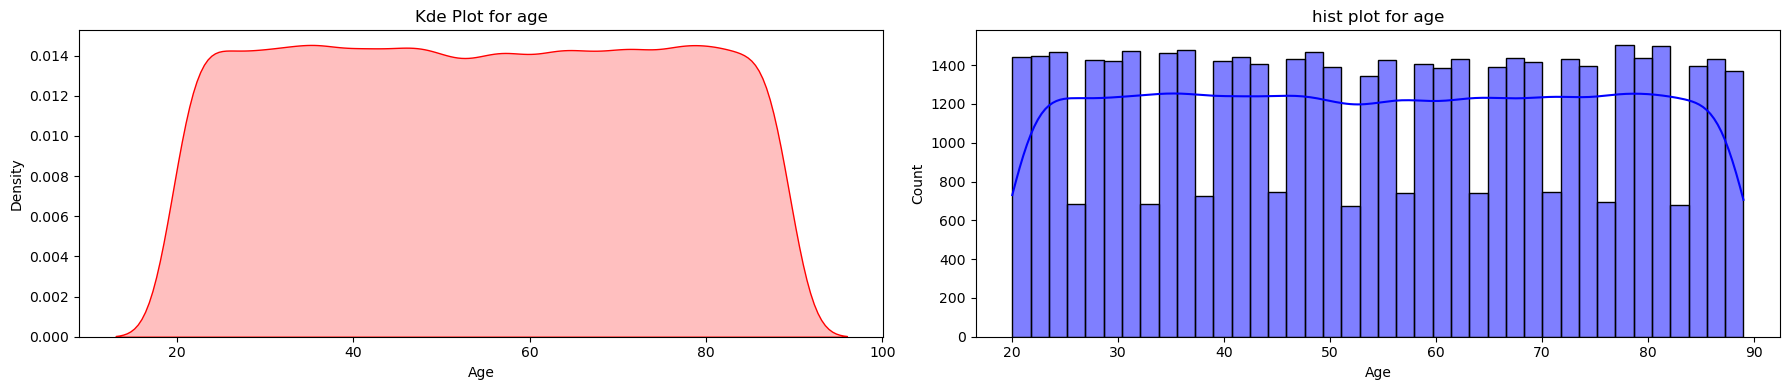

In [6]:
#ploting for each column
plt.figure(figsize=(18,4))


plt.subplot(1,2,1)
sns.kdeplot(data["Age"], fill=True, color="red")
plt.title("Kde Plot for age")

plt.subplot(1,2,2)
sns.histplot(data["Age"], bins=40, kde="False", color="blue")
plt.title("hist plot for age")

plt.tight_layout()
plt.show()

In [7]:
data["Age"].describe()

count    50000.000000
mean        54.421540
std         20.224451
min         20.000000
25%         37.000000
50%         54.000000
75%         72.000000
max         89.000000
Name: Age, dtype: float64

# Inference

range : 20 to 89
mean age : 54.42
interquartile range (IQR) : 37 (Q1) to 72 (Q3)
this suggest a broad representation of young and elderly patients in the dataset, which support age-based comparative analysis

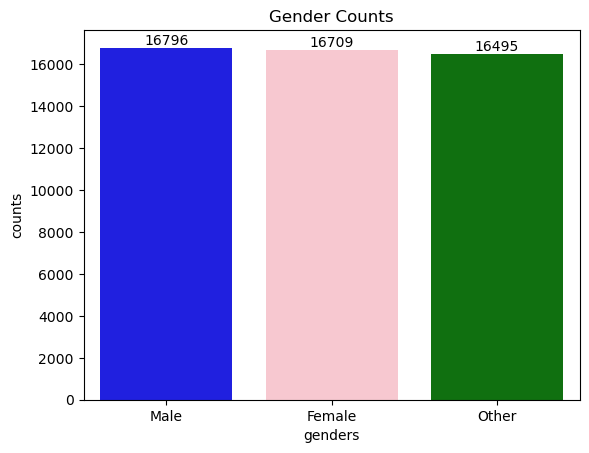

In [8]:
# Gender Column

sns.barplot(x= data["Gender"].value_counts().index,
            y=data["Gender"].value_counts().values,
            palette =["blue","pink","green"])
for i, v in enumerate(data["Gender"].value_counts()):
    plt.text(i,v,str(v), ha="center", va="bottom")

plt.title("Gender Counts")
plt.xlabel("genders")
plt.ylabel("counts")
plt.show()

this dataset contain three gender(male, female, other) with the most common being male(16796). Gender distribution is sufficient for evaluating  gender specific survival trends and sevrity outcomes

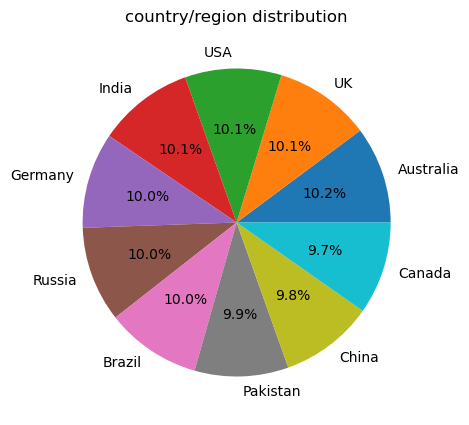

In [9]:
#country column
countries = data["Country_Region"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(x=countries.values,labels=countries.index, autopct="%0.1f%%")
plt.title("country/region distribution")
plt.show()

The dataset is evenly distributed across the ten countries, with each contributing about 10% of the total observations. This indicates balanced geographic representation and enables reliable cross-country comparative analysis.

In [10]:
data["Country_Region"].value_counts()

Country_Region
Australia    5092
UK           5060
USA          5060
India        5040
Germany      5024
Russia       5017
Brazil       5004
Pakistan     4926
China        4913
Canada       4864
Name: count, dtype: int64

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [12]:
data.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


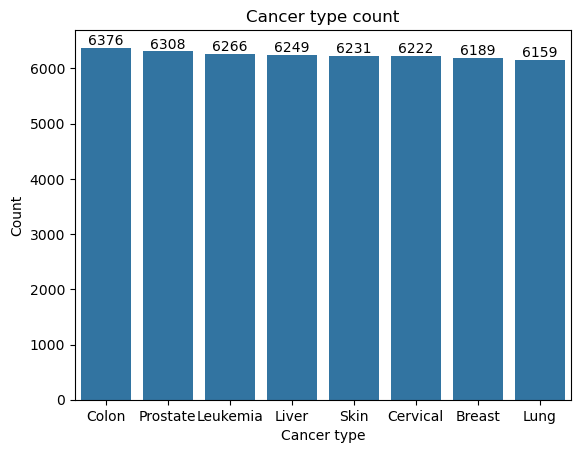

In [13]:
# cancer type
sns.barplot(x= data["Cancer_Type"].value_counts().index,y=data["Cancer_Type"].value_counts().values)

for i, v in enumerate(data["Cancer_Type"].value_counts()):
    plt.text(i,v, str(v),ha="center",va="bottom")

plt.title("Cancer type count")
plt.xlabel("Cancer type")
plt.ylabel("Count")
plt.show()

we have 8 types of cancer, with each cancer having approx same number of data point under label. most common are colon followed by prostate cancer 

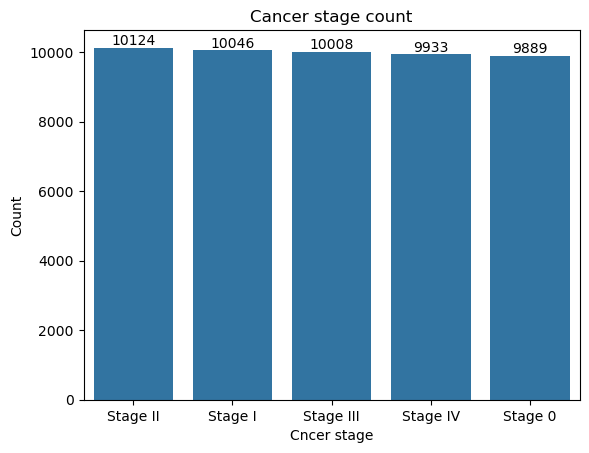

In [14]:
# cancer stage
data["Cancer_Stage"].value_counts()

sns.barplot(x=data["Cancer_Stage"].value_counts().index, y= data["Cancer_Stage"].value_counts().values)

for i, v in enumerate(data["Cancer_Stage"].value_counts()):
    plt.text(i,v, str(v), ha="center", va="bottom")

plt.title("Cancer stage count")
plt.xlabel("Cncer stage")
plt.ylabel("Count")
plt.show()

Cancer stage have 5 stage with values ranging from 0-4, with stage 2 the most commom one, and each stage have same number of data point under its labels

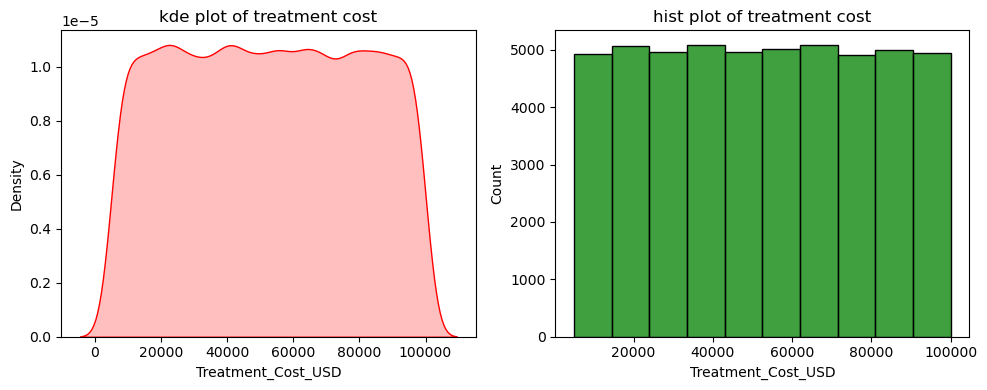

In [15]:
data["Treatment_Cost_USD"].value_counts()
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.kdeplot(data["Treatment_Cost_USD"], fill=True, color="red")
plt.title("kde plot of treatment cost")

plt.subplot(1,2,2)
sns.histplot(data["Treatment_Cost_USD"],bins=10, color="green")
plt.title("hist plot of treatment cost")
plt.tight_layout()
plt.show()


In [16]:
data["Treatment_Cost_USD"].describe()

count    50000.000000
mean     52467.298239
std      27363.229379
min       5000.050000
25%      28686.225000
50%      52474.310000
75%      76232.720000
max      99999.840000
Name: Treatment_Cost_USD, dtype: float64

treatment cost use have no skewness and thier are number of data point under each bin as obeserved by histogram

In [17]:
# Analyzing the risk factor
data.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='object')

In [18]:
columns_of_interest = ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
data[columns_of_interest].agg(["mean","std","min","max"])

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
std,2.885773,2.888399,2.888769,2.881579,2.894504
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


these variables have identical means and standard deviations, indicating they were likely designed on the same stadardized scale. they are essential in studing iteraction  effects on survival. 

# Determine the relationship between risk factors and cancer severty

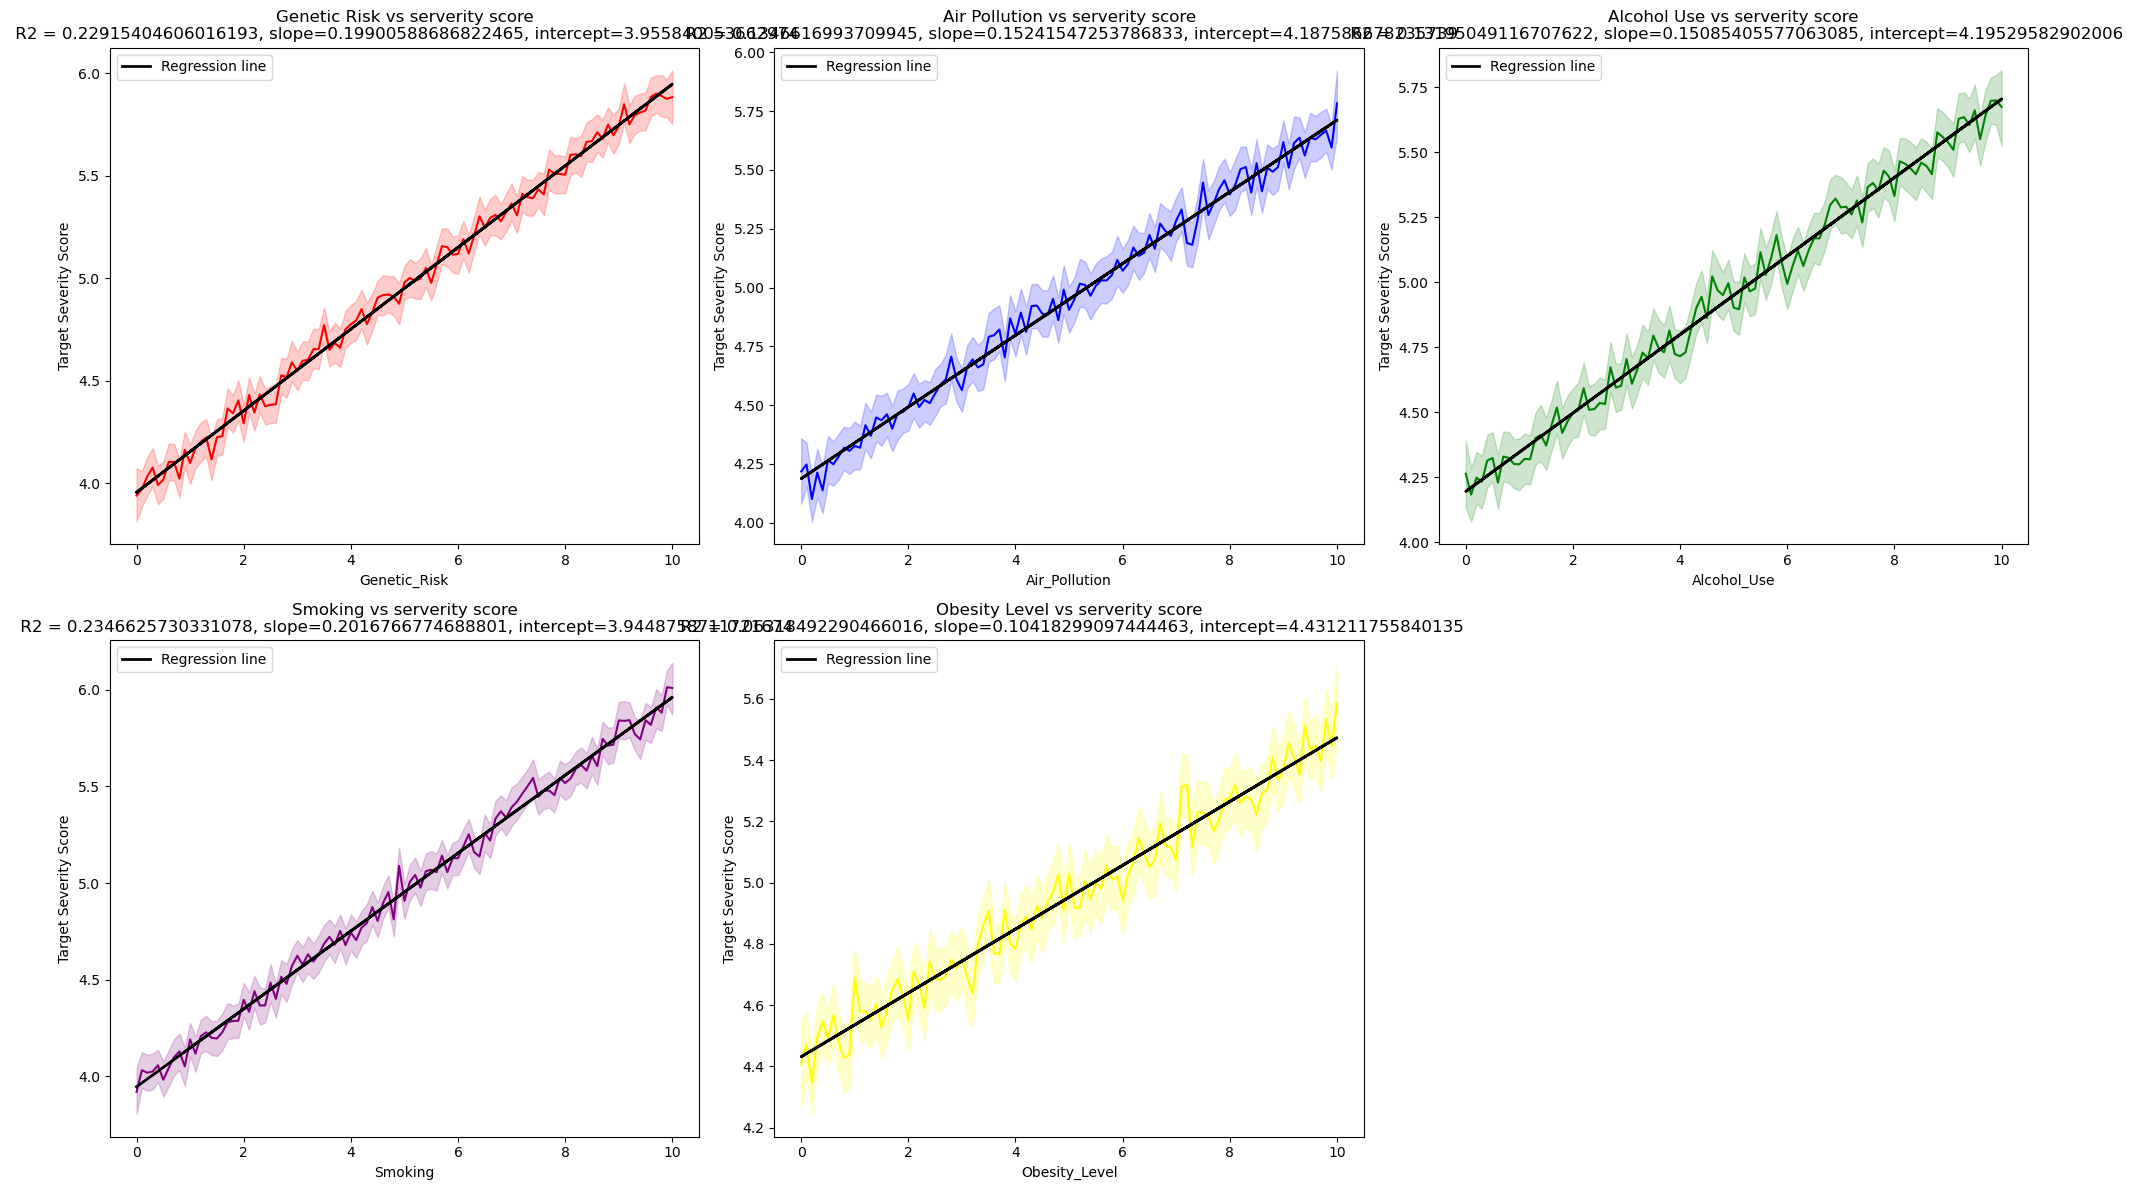

In [19]:
from scipy.stats import linregress
risk_factors = ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
title = ['Genetic Risk','Air Pollution', 'Alcohol Use', 'Smoking', 'Obesity Level']
colors= ["red","blue","green","purple","yellow"]
plt.figure(figsize=(20,12))
for i, (factor, title, color) in enumerate(zip(risk_factors,title,colors),1):
    plt.subplot(2,3,i)
    x=data[factor]
    y=data["Target_Severity_Score"]
    slope, intercept, r_value, p_value,std_err = linregress(x,y)
    r_square=r_value**2
    sns.lineplot(x=factor, y="Target_Severity_Score",data=data, color=color)
    plt.plot(x,x*slope+intercept,color="black", linewidth=2, label= "Regression line")
    plt.title(f"{title} vs serverity score\n R2 = {r_square}, slope={slope}, intercept={intercept}")
    plt.xlabel(factor)
    plt.ylabel("Target Severity Score")
    plt.legend()
plt.tight_layout()
plt.show()

Whenever you see a regression graph, ask these questions:

Is the slope positive or negative?
Is the relationship strong or weak?
How much does Y change when X changes?
Can this variable help predict Y?
What is the business conclusion?
1. Genetic Risk vs Severity Score
Observation
Positive slope ≈ 0.199
Intercept ≈ 3.96
R² ≈ 0.229

The line is increasing.

This means:

As Genetic Risk increases, the Severity Score also increases.

Interpretation of the slope

Slope = 0.199

Meaning:

For every 1-unit increase in Genetic Risk,

Severity Score increases by about

0.199 units

Interpretation of Intercept

Intercept ≈ 3.96

If Genetic Risk = 0,

Expected Severity Score ≈ 3.96.

Interpretation of R²

R² = 0.229

Meaning:

Only about 22.9% of the variation in Severity Score is explained by Genetic Risk.

The remaining 77.1% is explained by other factors.

Business Conclusion

Genetic Risk has a positive relationship with disease severity, but it is not the only factor affecting severity.

2. Air Pollution vs Severity Score

Slope ≈ 0.152

This means:

Every one-unit increase in Air Pollution increases Severity Score by about 0.15.

Again,

Positive relationship.

Business Interpretation

People living in areas with higher pollution tend to have slightly higher disease severity.

3. Alcohol Use vs Severity Score

Slope ≈ 0.151

Meaning:

Increasing alcohol consumption is associated with an increase in Severity Score.

Again,

Positive relationship.

Business Conclusion

Alcohol consumption appears to contribute positively to disease severity.

4. Smoking vs Severity Score

This graph is the strongest among all.

Slope ≈ 0.202

R² ≈ 0.235

Meaning

Every one-unit increase in Smoking

increases Severity Score by approximately

0.20.

Business Interpretation

Smoking has one of the strongest positive relationships with disease severity in this dataset.

Although R² is only about 23.5%, smoking still explains more variation than the other variables shown.

5. Obesity Level vs Severity Score

Slope ≈ 0.104

Smallest slope.

Meaning

Increasing obesity increases severity,

but

its effect is smaller compared to smoking or genetic risk.

# Analyze the propotion of early stage diagnoess by cancer type

In [20]:
data["Cancer_Type"].unique()

array(['Lung', 'Leukemia', 'Breast', 'Colon', 'Skin', 'Cervical',
       'Prostate', 'Liver'], dtype=object)

In [21]:
stage_count = data[data["Cancer_Type"]=="Lung"]["Cancer_Stage"].value_counts()
earlt_stage_count =  stage_count.get("Stage 0", 0) + stage_count.get("Stage I",0)
total_lung_cancer = stage_count.sum()
propotion = (earlt_stage_count/total_lung_cancer)*100
print(f"propotion of lung cancer diagnosed at stage 0 and stage 1 {propotion}") 

propotion of lung cancer diagnosed at stage 0 and stage 1 38.43156356551388


In [22]:
stage_count

Cancer_Stage
Stage II     1298
Stage IV     1286
Stage III    1208
Stage 0      1185
Stage I      1182
Name: count, dtype: int64

In [23]:
earlt_stage_count

np.int64(2367)

In [24]:
stage_count = data[data["Cancer_Type"]=="Leukemia"]["Cancer_Stage"].value_counts()
earlt_stage_count =  stage_count.get("Stage 0", 0) + stage_count.get("Stage I",0)
total_lung_cancer = stage_count.sum()
propotion = (earlt_stage_count/total_lung_cancer)*100
print(f"propotion of Leukemia cancer diagnosed at stage 0 and stage 1 {propotion}") 

propotion of Leukemia cancer diagnosed at stage 0 and stage 1 39.53080114905841


In [25]:
stage_count = data[data["Cancer_Type"]=="Breast"]["Cancer_Stage"].value_counts()
earlt_stage_count =  stage_count.get("Stage 0", 0) + stage_count.get("Stage I",0)
total_lung_cancer = stage_count.sum()
propotion = (earlt_stage_count/total_lung_cancer)*100
print(f"propotion of Breast cancer diagnosed at stage 0 and stage 1 {propotion}") 

propotion of Breast cancer diagnosed at stage 0 and stage 1 39.47325900791727


In [26]:
stage_count = data[data["Cancer_Type"]=="Skin"]["Cancer_Stage"].value_counts()
earlt_stage_count =  stage_count.get("Stage 0", 0) + stage_count.get("Stage I",0)
total_lung_cancer = stage_count.sum()
propotion = (earlt_stage_count/total_lung_cancer)*100
print(f"propotion of Skin cancer diagnosed at stage 0 and stage 1 {propotion}") 

propotion of Skin cancer diagnosed at stage 0 and stage 1 40.41084898090194


In [27]:
stage_count = data[data["Cancer_Type"]=="Cervical"]["Cancer_Stage"].value_counts()
earlt_stage_count =  stage_count.get("Stage 0", 0) + stage_count.get("Stage I",0)
total_lung_cancer = stage_count.sum()
propotion = (earlt_stage_count/total_lung_cancer)*100
print(f"propotion of Cervical cancer diagnosed at stage 0 and stage 1 {propotion}") 

propotion of Cervical cancer diagnosed at stage 0 and stage 1 39.85856637737062


In [28]:
stage_count = data[data["Cancer_Type"]=="Prostate"]["Cancer_Stage"].value_counts()
earlt_stage_count =  stage_count.get("Stage 0", 0) + stage_count.get("Stage I",0)
total_lung_cancer = stage_count.sum()
propotion = (earlt_stage_count/total_lung_cancer)*100
print(f"propotion of Prostate cancer diagnosed at stage 0 and stage 1 {propotion}") 

propotion of Prostate cancer diagnosed at stage 0 and stage 1 40.187064045656314


In [29]:
stage_count = data[data["Cancer_Type"]=="Liver"]["Cancer_Stage"].value_counts()
earlt_stage_count =  stage_count.get("Stage 0", 0) + stage_count.get("Stage I",0)
total_lung_cancer = stage_count.sum()
propotion = (earlt_stage_count/total_lung_cancer)*100
print(f"propotion of Liver cancer diagnosed at stage 0 and stage 1 {propotion}") 

propotion of Liver cancer diagnosed at stage 0 and stage 1 40.614498319731155


Interpretation

The results indicate that approximately 38–41% of patients across all cancer types were diagnosed at an early stage (Stage 0 or Stage I). The proportions are very similar among the different cancer types, suggesting that the dataset does not show large differences in early detection rates between cancers.

More specifically:

Liver cancer has the highest proportion of early-stage diagnoses (40.61%).
Skin cancer (40.41%) and Prostate cancer (40.19%) also have relatively high early detection rates.
Lung cancer has the lowest proportion of early-stage diagnoses (38.43%), indicating that a slightly smaller percentage of lung cancer cases were detected early compared with the other cancer types.
The differences between cancer types are small (about 2 percentage points), so they may not be statistically significant unless confirmed with a statistical test (e.g., a chi-square test).
Report-style interpretation

Early-stage diagnosis (Stage 0 and Stage I) accounted for approximately 38–41% of cases across all cancer types. Liver cancer showed the highest proportion of early-stage diagnoses (40.61%), while lung cancer had the lowest (38.43%). Overall, the results suggest that around two-fifths of patients in the dataset were diagnosed at an early stage, with only minor variation among different cancer types.

# identify key predictors of cancer serverity and survival years

In [30]:
features = ["Age",'Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
target=  ["Survival_Years","Target_Severity_Score"]

#calculate correlation
pearson_corr = data[features+target].corr(method="pearson")
spearman_corr = data[features+target].corr(method="spearman")


# slice out only the relationship with target variables 
pearson_result = pearson_corr[target]
spearman_result = spearman_corr[target]

# combine both 
correlation_df = pd.concat([pearson_result,spearman_result], axis= 1, keys=["pearson","spearman"])

In [31]:
correlation_df

pearson                             spearman  \
                      Survival_Years Target_Severity_Score Survival_Years   
Age                        -0.000147             -0.001481      -0.000149   
Genetic_Risk                0.001708              0.478700       0.001684   
Air_Pollution               0.000893              0.366963       0.000841   
Alcohol_Use                -0.000527              0.363250      -0.000543   
Smoking                     0.001371              0.484420       0.001372   
Obesity_Level               0.009771              0.251366       0.009780   
Survival_Years              1.000000              0.004161       1.000000   
Target_Severity_Score       0.004161              1.000000       0.003431   

                                             
                      Target_Severity_Score  
Age                               -0.002076  
Genetic_Risk                       0.472193  
Air_Pollution                      0.357528  
Alcohol_Use                        0.354694  
Smoking                            0.477881  
Obesity_Level                      0.243152  
Survival_Years                     0.003431  
Target_Severity_Score              1.000000

In [32]:
#random forest for target severity score

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score


# converting categorical column
categorical_col = ["Gender","Country_Region","Cancer_Type","Cancer_Stage"]
for col in categorical_col:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

print(data.head())
# preparing features and input 
x = data.drop(columns=["Patient_ID","Survival_Years","Target_Severity_Score", "Treatment_Cost_USD"])
y_severity = data["Target_Severity_Score"]

#train_test_split 
x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(x,y_severity, test_size=0.2, random_state=42)

# train the model
model = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42)
model.fit(x_train_s, y_train_s)

#evealueate the result
train_r2_severity = r2_score(y_train_s, model.predict(x_train_s))
test_r2_severity  = r2_score(y_test_s, model.predict(x_test_s))

  Patient_ID  Age  Gender  Country_Region  Year  Genetic_Risk  Air_Pollution  \
0  PT0000000   71       1               8  2021           6.4            2.8   
1  PT0000001   34       1               3  2021           1.3            4.5   
2  PT0000002   80       1               6  2023           7.4            7.9   
3  PT0000003   40       1               8  2015           1.7            2.9   
4  PT0000004   43       0               1  2017           5.1            2.8   

   Alcohol_Use  Smoking  Obesity_Level  Cancer_Type  Cancer_Stage  \
0          9.5      0.9            8.7            5             3   
1          3.7      3.9            6.3            3             0   
2          2.4      4.7            0.1            0             2   
3          4.8      3.5            2.7            2             1   
4          2.3      6.7            0.5            7             3   

   Treatment_Cost_USD  Survival_Years  Target_Severity_Score  
0            62913.44             5.9    

In [33]:
print(train_r2_severity)
print(test_r2_severity)

0.9689886894803543
0.7683892517466494


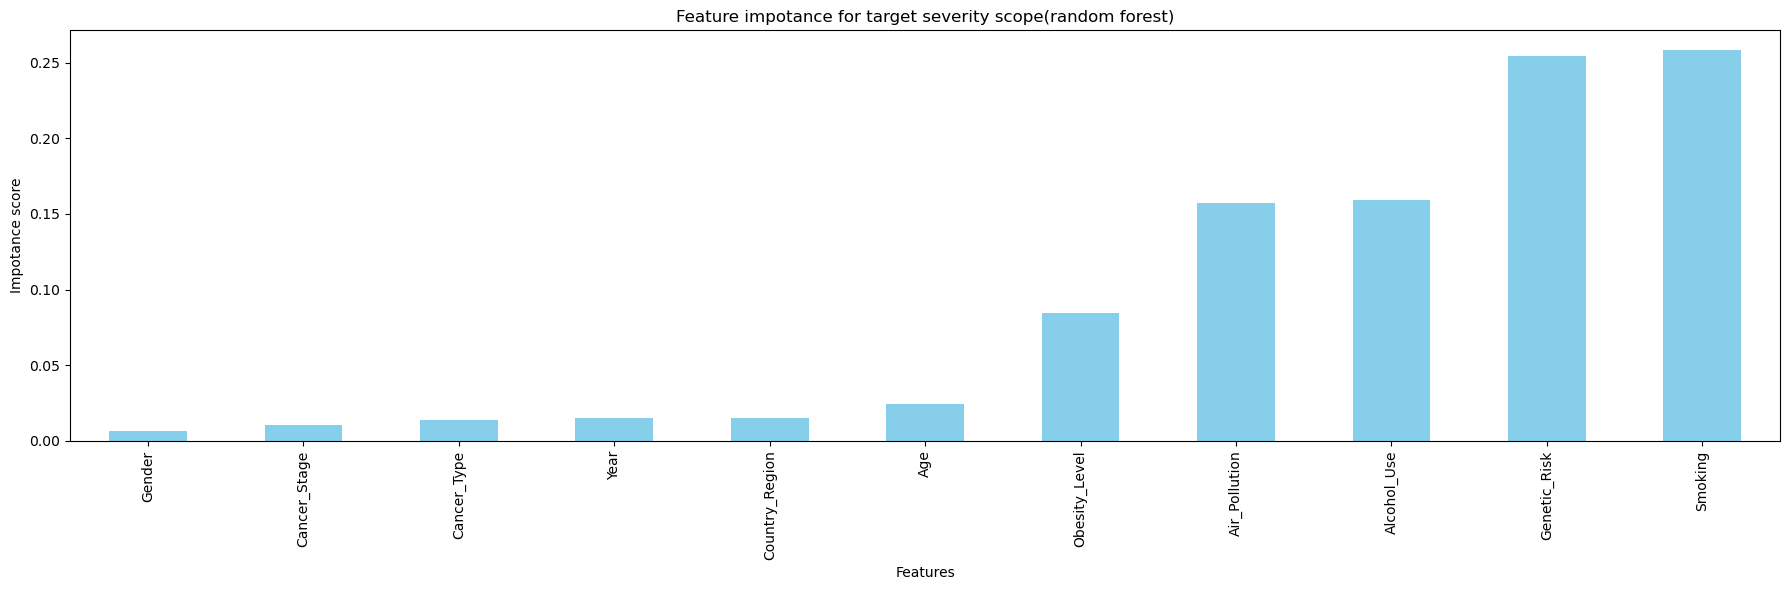

In [34]:
featur_importance_severity = pd.Series(model.feature_importances_, index = x.columns).sort_values(ascending=True)

# plotting of importance feature
plt.figure(figsize=(18,6))
featur_importance_severity.plot(kind="bar",color="skyblue")
plt.title("Feature impotance for target severity scope(random forest)")
plt.xlabel("Features")
plt.ylabel("Impotance score")
plt.tight_layout()
plt.show()

# Explore the economic burden of cancer treatment across different demographic and countries

In [35]:
df = pd.read_csv("global_cancer_patients_2015_2024.csv")

In [36]:
df

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [37]:
df["Age_Group"] = pd.cut(df["Age"],bins=[0,30,45,60,75,100],labels=["0-30","31-45","46-60","61-75","76+"])

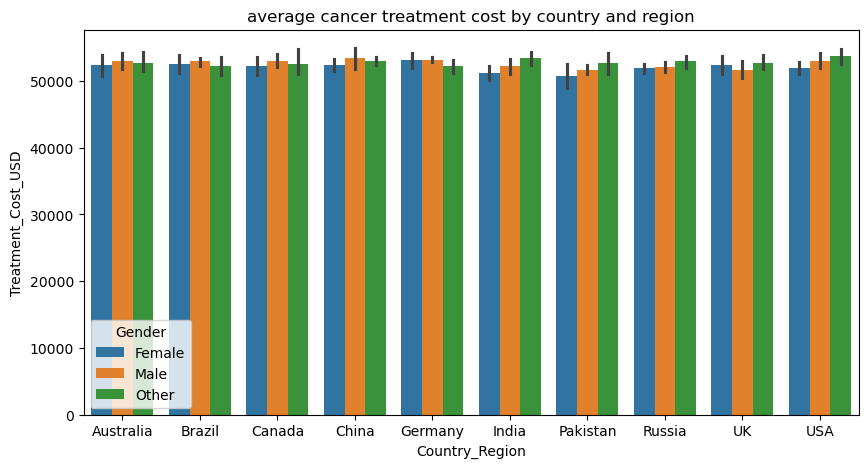

In [38]:
country_age_cost = df.groupby(["Country_Region","Age_Group","Gender"])["Treatment_Cost_USD"].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=country_age_cost,x="Country_Region",y="Treatment_Cost_USD", hue="Gender")
plt.title("average cancer treatment cost by country and region")
plt.show()

In [39]:
country_age_cost = df.groupby(["Country_Region","Age_Group"])["Treatment_Cost_USD"].mean().reset_index()

In [40]:
heatmap_data = country_age_cost.pivot(index="Age_Group",columns="Country_Region",values="Treatment_Cost_USD")

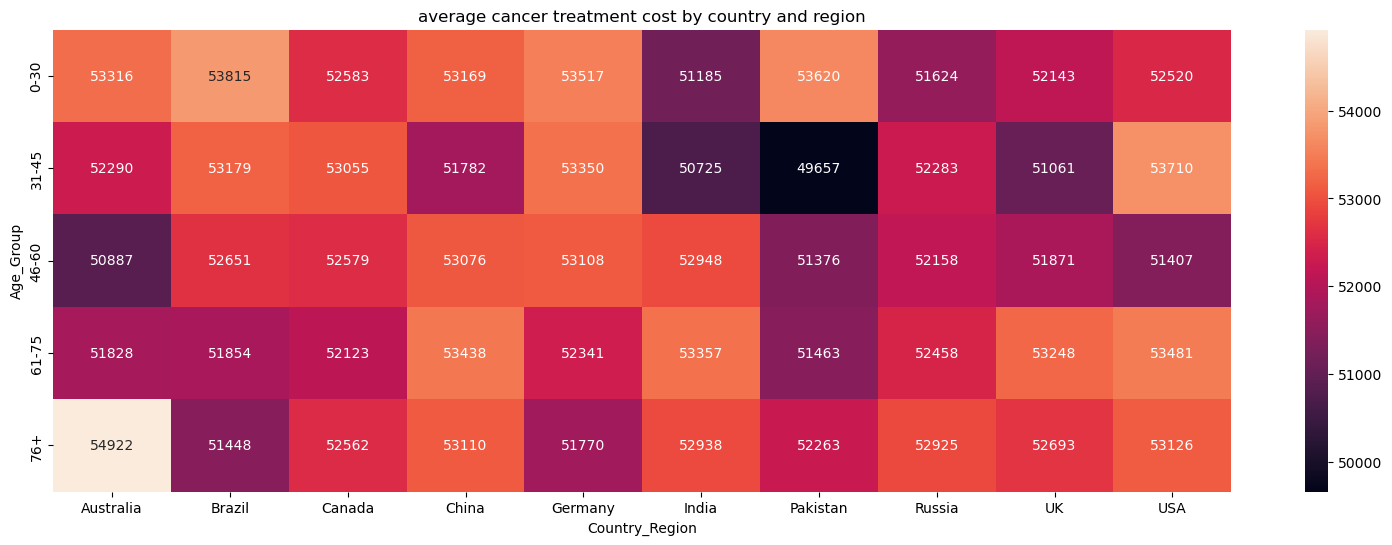

In [41]:
plt.figure(figsize=(19,6))
sns.heatmap(heatmap_data,annot=True,fmt=".0f")
plt.title("average cancer treatment cost by country and region")
plt.show()

The analysis indicates that the average cancer treatment cost remains relatively consistent across countries and age groups, ranging approximately from 50,000 to 55,000. Australia records the highest average treatment cost, particularly among patients aged 76+, while Pakistan records some of the lowest costs. No clear increasing or decreasing trend in treatment cost with age is observed.

# Assess wheather higher treatment cost is associcated with longer survival

Null Hypothesis (H0): there is no correlation between treatment cost and survival years.

Alternative Hypothesis (H1): there is a correlation (positive and negative) between treatment cost and survival years.



In [42]:
from scipy.stats import pearsonr, spearmanr

x = data["Treatment_Cost_USD"]
y= data["Survival_Years"]

#performing pearson correlation test
pearson_corr, pearson_p = pearsonr(x,y)
print(f"pearson correlation coefficient {pearson_corr}")
print(f"pearson p value{pearson_p}")

#performing pearson correlation test
spearman_corr, spearman_p = spearmanr(x,y)
print(f"spearman correlation coefficient {spearman_corr}")
print(f"spearman p value{spearman_p}")

alpha =0.05
def interpret_corr(corr,p, method):
    if p<alpha:
        print(f"{method}, we reject null hypothesis")
    else:
        print(f"{method}, we failed to reject null value")

interpret_corr(pearson_corr,pearson_p,"pearson")
interpret_corr(spearman_corr,spearman_p,"spearman")

pearson correlation coefficient -0.0004294054283021497
pearson p value0.9235082012963326
spearman correlation coefficient -0.0004454737292549569
spearman p value0.9206551702014918
pearson, we failed to reject null value
spearman, we failed to reject null value


<Axes: xlabel='Treatment_Cost_USD', ylabel='Survival_Years'>

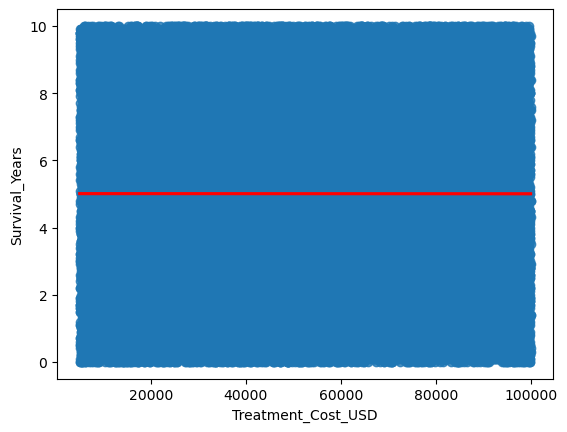

In [43]:
sns.regplot(x=x,y=y,line_kws={"color":"red"})

there is no relation between treatment cost and  survival years

# Evalauate if higher cancer stage lead to greater treatment costs and reduced survial years

In [44]:
df1 = df.copy()

In [45]:
stage_order = ['Stage 0','Stage I', 'Stage II', 'Stage III', 'Stage IV']
grouped_status = df1.groupby("Cancer_Stage")[["Treatment_Cost_USD","Survival_Years"]].mean().reset_index()

In [46]:
grouped_status

,Cancer_Stage,Treatment_Cost_USD,Survival_Years
0,Stage 0,52572.589493,5.015199
1,Stage I,52674.079638,5.012990
2,Stage II,52082.841258,4.995170
3,Stage III,52708.197506,5.036311
4,Stage IV,52302.471041,4.972596


treatment cost vs cancer stage 
null Hypothesis (h0): The average treatment cost is the same across all cancer stages.
Alternative Hypothesis (h1): at least one stage has a different average cost.

Survivei Years vs. Cencer stage

Null Hypothesis (Ho): The average survival yees are the same across all cancer stages.
Alternative Hypothesis(h1) :at least one Stage has a different survival duration.

In [47]:
grouped_costs=[]
grouped_survival=[]

for stage in stage_order:
    stage_data= df1[df1["Cancer_Stage"]==stage]
    cost= stage_data["Treatment_Cost_USD"]
    survival = stage_data["Survival_Years"]
    grouped_costs.append(cost)
    grouped_survival.append(survival)

In [48]:
#check for normality
from scipy.stats import shapiro, f_oneway
normal_cost=0
normal_survival=0
for i in range(len(stage_order)):
    cost_p = shapiro(grouped_costs[i]).pvalue
    survival_p = shapiro(grouped_survival[i]).pvalue
    print(f"{cost_p} for group {i}" )
    print(f"{survival_p} for group {i}")
    if cost_p<0.05:
        normal_cost+=1
    if survival_p<0.05:
        normal_survival+=1
    

1.5471821061637387e-47 for group 0
1.6291039522109283e-47 for group 0
7.306523956950957e-48 for group 1
7.575551046259697e-48 for group 1
8.943579643043388e-48 for group 2
4.041659465829829e-48 for group 2
5.267270033022367e-48 for group 3
1.3648520457944784e-47 for group 3
1.5838640189581322e-47 for group 4
2.2992598289836786e-47 for group 4


In [49]:
from scipy.stats import kruskal

In [50]:
kruskal_cost = kruskal(*grouped_costs)
kruskal_survival = kruskal(*grouped_survival)

p_cost = kruskal_cost.pvalue
p_survival = kruskal_survival.pvalue


In [51]:
print(p_cost)

0.4254451689062656


In [52]:
print(p_survival)

0.6033078729984223


In [53]:
# ---Kruskal wallies Test: Treatment Cost across Cancer Stages---

# 10 s:-gnificart difference in it—eatrent costs erong cerzer steges-
# Krus01-10112s Test: Survival Yeses across Cancer Stages =
# H. statistic:
# P-va•-ue: 0.6033
# Corc',usion: s',gnlflcart difference In surva-vai years ancng
# cancer
# stages.

# Examine whether higher genetic risk amplifies the negative effects of smoking on cancer severity

Null Hypothesis (H0): the interaction effect between gentic risk and smoking on cancer severity is not significant. 
    
Alternative Hypothesis (H1): the interaction effect between gentic risk and smoking on cancer severity is significant
(Genetic risk does not amplify or alter the effect of smoking)


In [68]:
import statsmodels.formula.api as smf
model = smf.ols("Target_Severity_Score ~ Genetic_Risk*Smoking", data=data).fit() 
model.summary2().tables[1].loc["Genetic_Risk:Smoking"]	

Coef.      -0.000228
Std.Err.    0.000471
t          -0.484187
P>|t|       0.628255
[0.025     -0.001150
0.975]      0.000694
Name: Genetic_Risk:Smoking, dtype: float64

The interaction between genetic risk and smoking was not statistically significant, β = -0.000228, SE = 0.000471, t = -0.484, p = .628. Therefore, we fail to reject the null hypothesis. There is insufficient evidence to conclude that genetic risk significantly amplifies or alters the effect of smoking on cancer severity.